# Scaling and weighting criteria

This tutorial focuses on two of the most common preprocessing steps in any
MCDA experiment: **scaling** (bringing every criterion to a comparable
range) and **weighting** (deciding how much each criterion matters).

## Case

A company has to choose a laptop model from five candidate suppliers
(*L1* to *L5*). Four criteria are considered:

1. **Price** (USD). Sense of optimality, $Minimize$.
2. **Battery** (hours of autonomy). Sense of optimality, $Maximize$.
3. **Weight** (kg). Sense of optimality, $Minimize$.
4. **Rating** (customer satisfaction, 1-10). Sense of optimality,
   $Maximize$.

The purchasing department already has an intuition about the relative
importance of each criterion: *Price* 40%, *Battery* 30%, *Weight* 20% and
*Rating* 10%.

The full decision matrix

In [1]:
import skcriteria as skc

dm = skc.mkdm(
    matrix=[
        [1200, 8, 1.8, 8],
        [800, 6, 2.2, 6],
        [1500, 10, 1.5, 9],
        [600, 5, 2.5, 5],
        [950, 7, 1.9, 7],
    ],
    objectives=[min, max, min, max],
    weights=[0.4, 0.3, 0.2, 0.1],
    alternatives=["L1", "L2", "L3", "L4", "L5"],
    criteria=["Price", "Battery", "Weight", "Rating"],
)

dm

,Price[▼ 0.4],Battery[▲ 0.3],Weight[▼ 0.2],Rating[▲ 0.1]
L1,1200,8,1.8,8
L2,800,6,2.2,6
L3,1500,10,1.5,9
L4,600,5,2.5,5
L5,950,7,1.9,7


## 1. Why scaling and weighting matter

Notice how *Price* lives in the hundreds/thousands while *Battery*,
*Weight* and *Rating* live in the single digits. This is a very common
situation and, if not addressed, it silently breaks any method that
combines criteria by addition, such as
[`WeightedSumModel`](https://en.wikipedia.org/wiki/Weighted_sum_model)
(the docstring of the class itself warns about this: *"adding apples and
oranges"*).

`WeightedSumModel` also requires every criterion to be for maximization,
so first we need to invert the two `Minimize` criteria (*Price* and
*Weight*) with `InvertMinimize`, which replaces every value $x$ by
$1/x$.

In [2]:
from skcriteria.preprocessing import invert_objectives

inverter = invert_objectives.InvertMinimize()
dmi = inverter.transform(dm)
dmi

,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,0.000833,8,0.555556,8
L2,0.001250,6,0.454545,6
L3,0.000667,10,0.666667,9
L4,0.001667,5,0.400000,5
L5,0.001053,7,0.526316,7


Let's naively evaluate this matrix, **without any scaling**, with
`WeightedSumModel`.

In [3]:
from skcriteria.agg.simple import WeightedSumModel

naive_rank = WeightedSumModel().evaluate(dmi)
naive_rank

Alternatives,L1,L2,L3,L4,L5
Rank,2,4,1,5,3


In [4]:
naive_rank.e_.score

array([3.31144444, 2.49140909, 4.0336    , 2.08066667, 2.90568421])

At a first glance the ranking looks reasonable, but let's inspect
*how much* each criterion actually contributed to the score of `L1`:

In [5]:
import pandas as pd

contributions = dmi.matrix.loc["L1"] * dm.weights
contributions

Criteria
Price      0.000333
Battery    2.400000
Weight     0.111111
Rating     0.800000
dtype: float64

Even though *Price* was declared as the **most important**
criterion (40% of the weight), after the inversion its values collapsed to
the $[0.0007, 0.0017]$ range, so its contribution to the final score is
completely negligible compared to *Battery* or *Rating*. In practice,
`WeightedSumModel` is deciding almost exclusively based on *Battery* and
*Rating*, ignoring the purchasing department's priorities.

This is exactly the problem that **scaling** solves: bringing every
criterion to a comparable range *before* combining them, so that the
`weights` actually reflect the importance the decision-maker intended.

## 2. Scalers

*Scikit-criteria* offers the `skcriteria.preprocessing.scalers` module
with several strategies. Every scaler accepts a `target` parameter that
can be:

- `target="matrix"`: only the decision matrix $A$ is scaled.
- `target="weights"`: only the weights $w$ are scaled.
- `target="both"`: both $A$ and $w$ are scaled.

The available scalers are:

- `MinMaxScaler`: rescales every criterion to a fixed range (`(0, 1)` by
  default) using the min and the max.
- `StandarScaler`: standardizes by removing the mean and scaling to unit
  variance (thin wrapper around
  [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)).
- `VectorScaler`: divides every value by the norm of the vector defined by
  the criterion.
- `SumScaler`: divides every value by the total sum of the criterion.
- `MaxAbsScaler`: divides every value by the maximum absolute value of the
  criterion (`MaxScaler` is a deprecated alias of this one).
- `CenitDistanceMatrixScaler`: relative score with respect to an ideal and
  an anti-ideal alternative (used internally, for example, by `CRITIC`;
  we will meet it again in the next section).

Let's compare how the four main scalers transform the *matrix* of our
already-inverted decision matrix (`dmi`).

In [6]:
from skcriteria.preprocessing import scalers

for scaler in (
    scalers.MinMaxScaler(target="matrix"),
    scalers.StandarScaler(target="matrix"),
    scalers.VectorScaler(target="matrix"),
    scalers.MaxAbsScaler(target="matrix"),
):
    print(scaler)
    display(scaler.transform(dmi))

<MinMaxScaler [clip=False, criteria_range=(0.0, 1.0), target='matrix']>


,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,0.166667,0.6,0.583333,0.75
L2,0.583333,0.2,0.204545,0.25
L3,0.000000,1.0,1.000000,1.00
L4,1.000000,0.0,0.000000,0.00
L5,0.385965,0.4,0.473684,0.50


<StandarScaler [target='matrix', with_mean=True, with_std=True]>


,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,-0.749236,0.464991,0.383515,0.707107
L2,0.449037,-0.697486,-0.725247,-0.707107
L3,-1.228545,1.627467,1.603153,1.414214
L4,1.647310,-1.278724,-1.323979,-1.414214
L5,-0.118566,-0.116248,0.062558,0.000000


<VectorScaler [target='matrix']>


,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,0.324690,0.483298,0.470083,0.500979
L2,0.487034,0.362473,0.384614,0.375735
L3,0.259752,0.604122,0.564100,0.563602
L4,0.649379,0.302061,0.338460,0.313112
L5,0.410134,0.422885,0.445342,0.438357


<MaxAbsScaler [target='matrix']>


,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,0.500000,0.8,0.833333,0.888889
L2,0.750000,0.6,0.681818,0.666667
L3,0.400000,1.0,1.000000,1.000000
L4,1.000000,0.5,0.600000,0.555556
L5,0.631579,0.7,0.789474,0.777778


<div class="alert alert-info">

**Note:**

`MinMaxScaler` and `MaxAbsScaler` keep every value between `0` and `1`,
`VectorScaler` normalizes by the Euclidean norm of the column (used, for
example, by `TOPSIS`) and `StandarScaler` can produce negative values,
which makes it unsuitable for methods like `WeightedSumModel` or
`WeightedProductModel` that reject values `<= 0`.

</div>

For our `WeightedSumModel` case, any of `MinMaxScaler`, `VectorScaler`,
`SumScaler` or `MaxAbsScaler` would work, since all of them keep the
values positive. Let's fix the naive ranking of Part 1 using
`SumScaler`.

In [7]:
dmt = scalers.SumScaler(target="matrix").transform(dmi)
dmt

,Price[▲ 0.4],Battery[▲ 0.3],Weight[▲ 0.2],Rating[▲ 0.1]
L1,0.152366,0.222222,0.213422,0.228571
L2,0.228549,0.166667,0.174618,0.171429
L3,0.121893,0.277778,0.256107,0.257143
L4,0.304731,0.138889,0.153664,0.142857
L5,0.192462,0.194444,0.202189,0.200000


In [8]:
fixed_rank = WeightedSumModel().evaluate(dmt)
fixed_rank

Alternatives,L1,L2,L3,L4,L5
Rank,5,4,1,2,3


In [9]:
display(naive_rank)
display(fixed_rank)

Alternatives,L1,L2,L3,L4,L5
Rank,2,4,1,5,3


Alternatives,L1,L2,L3,L4,L5
Rank,5,4,1,2,3


Once every criterion is on a comparable scale, `L4` (the cheapest
laptop) climbs from the last position to the second one, and the overall
ranking now actually reflects the declared weights. From here on we will
keep working with the scaled matrix `dmt`.

## 3. Statistical weighters

So far we used the weights provided "by hand" by the purchasing
department. But *Scikit-criteria* can also **derive** the weights directly
from the data, using the `skcriteria.preprocessing.weighters` module.

The simplest weighters only look at the statistical properties of each
criterion (they ignore the `weights` originally set on the matrix):

- `EqualWeighter`: assigns the same weight to every criterion.
- `StdWeighter`: uses the standard deviation of each criterion — the more
  a criterion varies across alternatives, the more it can discriminate
  between them, so it gets a higher weight.
- `EntropyWeighter`: uses the complement of the
  [entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory))
  of each criterion.
- `GiniWeighter`: uses the
  [Gini coefficient](https://en.wikipedia.org/wiki/Gini_coefficient) of
  each criterion <cite data-cite="li2009new">[li2009new]</cite>.

<div class="alert alert-warning">

Since these weighters only look at raw dispersion, they are sensitive to
the scale of the data. It is recommended to apply them **after** scaling
the matrix, exactly as we did in Part 2.

</div>

In [10]:
from skcriteria.preprocessing import weighters

statistical_weighters = {
    "EqualWeighter": weighters.EqualWeighter(),
    "StdWeighter": weighters.StdWeighter(),
    "EntropyWeighter": weighters.EntropyWeighter(),
    "GiniWeighter": weighters.GiniWeighter(),
}

weight_comparison = pd.DataFrame(
    {name: w.transform(dmt).weights for name, w in statistical_weighters.items()}
)
weight_comparison

,EqualWeighter,StdWeighter,EntropyWeighter,GiniWeighter
Price,0.25,0.340401,0.436708,0.338695
Battery,0.25,0.255878,0.247792,0.255507
Weight,0.25,0.187382,0.133744,0.186793
Rating,0.25,0.216340,0.181756,0.219006


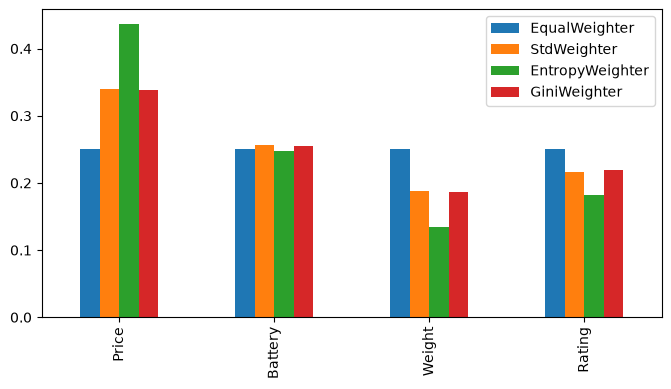

In [11]:
weight_comparison.plot.bar(figsize=(8, 4));

Interestingly, `StdWeighter`, `EntropyWeighter` and `GiniWeighter`
all agree that *Price* is the criterion that varies the most across our
five laptops, and consequently the one that best discriminates between
them — which, in this particular dataset, happens to align with the
purchasing department's original intuition (*Price* was set to 40%).
`EqualWeighter`, as expected, simply ignores the data and splits the
weight evenly.

## 4. Correlation and expert-based weighters

A second family of weighters takes into account either the correlation
between criteria, or weights already provided by an expert:

- `CRITIC` (CRiteria Importance Through Intercriteria Correlation):
  combines the contrast intensity (standard deviation) of a criterion with
  how much it *conflicts* (is uncorrelated) with the rest
  <cite data-cite="diakoulaki1995determining">[diakoulaki1995determining]</cite>.
  A criterion that is highly correlated with the others carries redundant
  information and gets a lower weight.
- `MEREC` (MEthod based on the Removal Effects of Criteria): removes each
  criterion one at a time and measures how much the overall evaluation of
  the alternatives changes; criteria whose removal changes the evaluation
  the most get the highest weight
  <cite data-cite="keshavarz2021determination">[keshavarz2021determination]</cite>.
- `RANCOM` (RANking COMparison): takes the weights already assigned by an
  expert and recalculates them based on **pairwise rank comparisons**
  instead of their raw magnitude, which reduces the impact of small
  inconsistencies in the expert's original numbers
  <cite data-cite="WIECKOWSKI2023106114">[WIECKOWSKI2023106114]</cite>.

Unlike the weighters of Part 3, `CRITIC` and `MEREC` take the `objectives`
into account and scale the matrix internally, so they can be applied
directly to the *original*, unscaled decision matrix `dm`.

In [12]:
print("CRITIC :", weighters.CRITIC().transform(dm).weights.to_numpy())
print("MEREC  :", weighters.MEREC().transform(dm).weights.to_numpy())

CRITIC : [0.49725451 0.16746852 0.16476909 0.17050787]
MEREC  : [0.35570444 0.24180828 0.17625799 0.22622929]


/home/juan/proyectos/skcriteria/src/skcriteria/preprocessing/weighters.py:422: UserWarning: Although CRITIC can operate with minimization objectives, this is not recommended. Consider reversing the weights for these cases.
  warnings.warn(


Both agree, once again, that *Price* deserves the largest weight
in this dataset.

`RANCOM` works differently: it does not look at the matrix at all, only
at the `weights` already present in the decision matrix (the ones
provided by the purchasing department).

In [13]:
rancom_rank = weighters.RANCOM().transform(dm)
print("Original weights:", dm.weights.to_numpy())
print("RANCOM weights  :", rancom_rank.weights.to_numpy())

Original weights: [0.4 0.3 0.2 0.1]
RANCOM weights  : [0.4375 0.3125 0.1875 0.0625]


/home/juan/proyectos/skcriteria/src/skcriteria/preprocessing/weighters.py:688: UserWarning: RANCOM method proves to be a more suitable solution to handle the expert inaccuracies for the problems with 5 or more criteria. Despite this, nothing prevents its use with four or fewer.
  warnings.warn(


<div class="alert alert-info">

**Note:**

`RANCOM` raises a `UserWarning` (as seen above) when used with less than
five criteria, since the original paper suggests the method works better
with five or more; nothing prevents its use with fewer, as in our
four-criteria example.

</div>

The relative order between criteria is preserved (*Price* stays the most
important and *Rating* the least), but the exact values are slightly
recalibrated based on the rank comparisons rather than the raw
percentages.

## 5. Putting it all together with pipelines

The most convenient way to combine a scaler, a weighter and a MCDA method
is to use a `pipeline` (already introduced in the
[Quick Start](quickstart.ipynb) and [Dominance](sufdom.ipynb) tutorials).

Let's build three pipelines that only differ in **how the weights are
derived**, and rank our laptops with
[TOPSIS](https://en.wikipedia.org/wiki/TOPSIS) in every case:

1. `EqualWeighter`: ignore the department's opinion, treat every
   criterion equally.
2. `CRITIC`: derive the weights from the data.
3. `EntropyWeighter`: derive the weights from the data, using a different
   statistical criterion.

<div class="alert alert-warning">

Since `TOPSIS` uses distances as a comparison metric, we use
`NegateMinimize` instead of `InvertMinimize` to invert the `Minimize`
criteria (see the [Quick Start](quickstart.ipynb) tutorial for the
distinction).

</div>

In [14]:
from skcriteria.pipelines import mkpipe
from skcriteria.agg.topsis import TOPSIS

def make_pipe(weighter):
    return mkpipe(
        invert_objectives.NegateMinimize(),
        scalers.VectorScaler(target="matrix"),
        weighter,
        TOPSIS(),
    )

rank_equal = make_pipe(weighters.EqualWeighter()).evaluate(dm)
rank_critic = make_pipe(weighters.CRITIC()).evaluate(dm)
rank_entropy = make_pipe(weighters.EntropyWeighter()).evaluate(dm)

display(rank_equal, rank_critic, rank_entropy)

Alternatives,L1,L2,L3,L4,L5
Rank,3,4,1,5,2


Alternatives,L1,L2,L3,L4,L5
Rank,4,2,5,1,3


Alternatives,L1,L2,L3,L4,L5
Rank,4,2,5,1,3


We can use `RanksComparator` (introduced in the
[Rankings comparison](rankcmp.ipynb) tutorial) to see how different these
three rankings really are.

In [15]:
from skcriteria.cmp import mkrank_cmp

rcmp = mkrank_cmp(rank_equal, rank_critic, rank_entropy)
rcmp.to_dataframe()

Method,TOPSIS_1,TOPSIS_2,TOPSIS_3
Alternatives,,,
L1,3,4,4
L2,4,2,2
L3,1,5,5
L4,5,1,1
L5,2,3,3


In [16]:
rcmp.corr()

Method,TOPSIS_1,TOPSIS_2,TOPSIS_3
Method,,,
TOPSIS_1,1.0,-0.8,-0.8
TOPSIS_2,-0.8,1.0,1.0
TOPSIS_3,-0.8,1.0,1.0


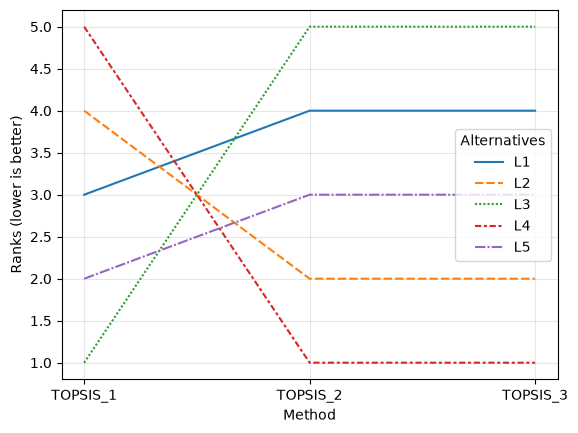

In [17]:
rcmp.plot.flow();

Simply changing *how the weights are computed* — while keeping the
scaler and the MCDA method fixed — is enough to produce noticeably
different rankings: the `EqualWeighter` pipeline is almost the exact
opposite of the two data-driven ones. This is why choosing (or deriving)
weights carefully is just as important as choosing the aggregation
method itself.